# Сравнение DFA на CPU и CUDA

Сравнение времени работы и результатов DFA с NumPy и CuPy.
Используются четыре длины гауссовского белого шума и 15 парных повторов.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

project_dir = Path(".")
while not (project_dir / "StatTools").is_dir():
    parent = project_dir / ".."
    if parent.resolve() == project_dir.resolve():
        raise FileNotFoundError("Откройте ноутбук внутри FluctuationAnalysisTools.")
    project_dir = parent

sys.path.insert(0, str(project_dir.resolve()))
from StatTools.analysis.dfa import dfa


## Параметры эксперимента

In [2]:
SIZES = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
REPEATS = 15
DEGREE = 2
N_INTEGRAL = 1
S_MIN = 5
RTOL = 1e-7
ATOL = 1e-10

## Измерение времени

Измеряется полный вызов DFA, включая передачу данных CPU–GPU.

In [3]:
def measure_dfa(data, backend):
    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    start = perf_counter()
    scales, f2 = dfa(
        data, degree=DEGREE, n_integral=N_INTEGRAL,
        s_min=S_MIN, processes=1, backend=backend,
    )

    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    elapsed = perf_counter() - start
    return elapsed, scales, f2

## Параметры

In [4]:
import cupy as cp

gpu_name = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

parameters = {
    "sizes": SIZES,
    "repeats": REPEATS,
    "degree": DEGREE,
    "n_integral": N_INTEGRAL,
    "s_min": S_MIN,
    "rtol": RTOL,
    "atol": ATOL,
    "processes": 1,
    "signal": "Gaussian white noise",
    "dtype": "float64",
    "gpu": gpu_name,
    "numpy": np.__version__,
    "cupy": cp.__version__,
}

print("GPU:", gpu_name)
display(pd.Series(parameters, name="value").to_frame())


GPU: NVIDIA GeForce RTX 5080


,value
sizes,"[1000, 10000, 100000, 1000000, 10000000, 10000..."
repeats,15
degree,2
n_integral,1
s_min,5
rtol,0.0
atol,0.0
processes,1
signal,Gaussian white noise
dtype,float64


## Запуск эксперимента

Для каждой длины создаём один случайный сигнал и передаём его обеим версиям DFA.
Перед замерами выполняем по одному прогреву на CPU и GPU.
В каждом повторе запускаем обе версии, меняя порядок запуска.

In [5]:
rng = np.random.default_rng()

signals = {}
dfa_results = {}
records = []

for n in SIZES:
    data = rng.standard_normal(n)
    signals[n] = data

    for backend in ["cpu", "cuda"]:
        print(f"N={n}: прогрев {backend}", flush=True)
        measure_dfa(data, backend)

    for repeat in range(1, REPEATS + 1):
        order = ["cpu", "cuda"] if repeat % 2 else ["cuda", "cpu"]
        measured = {}

        for backend in order:
            print(f"N={n}, повтор {repeat}/{REPEATS}, {backend}", flush=True)
            measured[backend] = measure_dfa(data, backend)
            print(f"Время: {measured[backend][0]:.3f} с", flush=True)

        cpu_time, cpu_scales, cpu_f2 = measured["cpu"]
        cuda_time, cuda_scales, cuda_f2 = measured["cuda"]

        np.testing.assert_array_equal(cpu_scales, cuda_scales)
        assert cpu_f2.shape == cuda_f2.shape and cpu_f2.size > 0
        assert np.isfinite(cpu_f2).all() and np.isfinite(cuda_f2).all()

        matches = bool(np.allclose(cuda_f2, cpu_f2, rtol=RTOL, atol=ATOL))

        dfa_results[(n, repeat)] = {
            "s_cpu": cpu_scales,
            "f2_cpu": cpu_f2,
            "s_cuda": cuda_scales,
            "f2_cuda": cuda_f2,
        }

        records.append({
            "size": n,
            "repeat": repeat,
            "first_backend": order[0],
            "cpu_time": cpu_time,
            "cuda_time": cuda_time,
            "max_abs_error": float(np.max(np.abs(cpu_f2 - cuda_f2))),
            "results_match": matches,
        })

        assert matches, "Результаты CPU/CUDA различаются больше допустимого."

results = pd.DataFrame(records)
results["speedup"] = results["cpu_time"] / results["cuda_time"]

print("Замеры завершены.")
display(results.head())
display(results.groupby("size").size().rename("completed_pairs").to_frame())


N=1000: прогрев cpu
N=1000: прогрев cuda
N=1000, повтор 1/15, cpu
Время: 0.001 с
N=1000, повтор 1/15, cuda
Время: 0.009 с
N=1000, повтор 2/15, cuda
Время: 0.009 с
N=1000, повтор 2/15, cpu
Время: 0.001 с
N=1000, повтор 3/15, cpu
Время: 0.001 с
N=1000, повтор 3/15, cuda
Время: 0.009 с
N=1000, повтор 4/15, cuda
Время: 0.009 с
N=1000, повтор 4/15, cpu
Время: 0.001 с
N=1000, повтор 5/15, cpu
Время: 0.001 с
N=1000, повтор 5/15, cuda
Время: 0.009 с
N=1000, повтор 6/15, cuda
Время: 0.008 с
N=1000, повтор 6/15, cpu
Время: 0.001 с
N=1000, повтор 7/15, cpu
Время: 0.001 с
N=1000, повтор 7/15, cuda
Время: 0.009 с
N=1000, повтор 8/15, cuda
Время: 0.008 с
N=1000, повтор 8/15, cpu
Время: 0.001 с
N=1000, повтор 9/15, cpu
Время: 0.001 с
N=1000, повтор 9/15, cuda
Время: 0.008 с
N=1000, повтор 10/15, cuda
Время: 0.008 с
N=1000, повтор 10/15, cpu
Время: 0.001 с
N=1000, повтор 11/15, cpu
Время: 0.001 с
N=1000, повтор 11/15, cuda
Время: 0.009 с
N=1000, повтор 12/15, cuda
Время: 0.008 с
N=1000, повтор 12/15, 

,size,repeat,first_backend,cpu_time,cuda_time,max_abs_error,results_match,speedup
0,1000,1,cpu,0.000634,0.008762,8.881784e-16,True,0.072361
1,1000,2,cuda,0.000615,0.008651,8.881784e-16,True,0.071067
2,1000,3,cpu,0.000813,0.008655,8.881784e-16,True,0.093896
3,1000,4,cuda,0.000822,0.008699,8.881784e-16,True,0.094541
4,1000,5,cpu,0.000688,0.009012,8.881784e-16,True,0.076321


,completed_pairs
size,
1000,15
10000,15
100000,15
1000000,15
10000000,15
100000000,15


## Результаты

In [6]:
assert results["results_match"].all(), "Нужно проверить расхождение CPU/CUDA."
assert (results[["cpu_time", "cuda_time"]] > 0).all().all()

display(results)


,size,repeat,first_backend,cpu_time,cuda_time,max_abs_error,results_match,speedup
0,1000,1,cpu,0.000634,0.008762,8.881784e-16,True,0.072361
1,1000,2,cuda,0.000615,0.008651,8.881784e-16,True,0.071067
2,1000,3,cpu,0.000813,0.008655,8.881784e-16,True,0.093896
3,1000,4,cuda,0.000822,0.008699,8.881784e-16,True,0.094541
4,1000,5,cpu,0.000688,0.009012,8.881784e-16,True,0.076321
...,...,...,...,...,...,...,...,...
85,100000000,11,cpu,55.573193,2.863550,1.559965e-08,True,19.407096
86,100000000,12,cuda,55.593027,2.484601,1.554145e-08,True,22.375030
87,100000000,13,cpu,55.625271,2.688315,1.548324e-08,True,20.691499
88,100000000,14,cuda,54.869162,2.487046,1.559965e-08,True,22.061984


## Сводные результаты

Рассчитываем среднее, медиану и стандартное отклонение времени работы.
Ускорение — время CPU, делённое на время GPU в том же повторе.
Если оно больше 1, GPU работает быстрее.
Также проверяем, совпадают ли результаты CPU и GPU в пределах заданных допусков.


In [7]:
times = results.melt(
    id_vars=["size", "repeat"],
    value_vars=["cpu_time", "cuda_time"],
    var_name="backend",
    value_name="seconds",
)
times["backend"] = times["backend"].map({
    "cpu_time": "cpu",
    "cuda_time": "cuda",
})

time_summary = times.groupby(["size", "backend"])["seconds"].agg(
    ["count", "mean", "median", "std", "min", "max"],
)
comparison = results.groupby("size").agg(
    median_speedup=("speedup", "median"),
    max_abs_error=("max_abs_error", "max"),
    results_match=("results_match", "all"),
)

display(time_summary)
display(comparison)


count       mean     median       std        min        max
size      backend                                                             
1000      cpu         15   0.000768   0.000808  0.000122   0.000561   0.000983
          cuda        15   0.008488   0.008412  0.000294   0.008065   0.009012
10000     cpu         15   0.003046   0.002951  0.000620   0.002487   0.005002
          cuda        15   0.015428   0.015244  0.000550   0.014936   0.017028
100000    cpu         15   0.023911   0.023210  0.002685   0.020104   0.030539
          cuda        15   0.022830   0.022070  0.001845   0.020579   0.026137
1000000   cpu         15   0.464758   0.437010  0.075432   0.423075   0.651508
          cuda        15   0.040822   0.035723  0.011018   0.034348   0.065929
10000000  cpu         15   6.550174   7.024930  1.522993   4.939104   8.079704
          cuda        15   0.349604   0.318305  0.089340   0.254632   0.491092
100000000 cpu         15  55.829920  55.419549  2.014462  54.869162  63.050747
          cuda        15   2.630730   2.662345  0.146420   2.484601   2.863550

,median_speedup,max_abs_error,results_match
size,,,
1000,0.094290,8.881784e-16,True
10000,0.197596,4.263256e-14,True
100000,0.989827,3.979039e-12,True
1000000,12.282847,2.273737e-11,True
10000000,19.488205,5.675247e-10,True
100000000,20.691499,1.571607e-08,True


## Статистическое сравнение

Для каждого повтора вычисляем разницу во времени работы CPU и GPU.
Тестом Шапиро—Уилка проверяем, похоже ли распределение этих разностей на нормальное.
Парным t-тестом проверяем, различается ли среднее время работы двух версий DFA.
Для t-теста предполагаем, что повторы независимы, а разности имеют нормальное распределение.
При p ≥ 0.05 тест Шапиро не обнаружил отклонения от нормальности, но не доказал её.


In [8]:
test_records = []

for n, group in results.groupby("size"):
    difference = group["cpu_time"] - group["cuda_time"]
    shapiro_p = np.nan
    ttest_p = np.nan

    if len(group) >= 3 and np.std(difference) > 0:
        shapiro_p = stats.shapiro(difference).pvalue

    if len(group) >= 2 and np.std(difference) > 0:
        ttest_p = stats.ttest_rel(
            group["cpu_time"],
            group["cuda_time"],
        ).pvalue

    test_records.append({
        "size": n,
        "pairs": len(group),
        "mean_difference": difference.mean(),
        "shapiro_p": shapiro_p,
        "ttest_p": ttest_p,
    })

test_results = pd.DataFrame(test_records)
display(test_results)


,size,pairs,mean_difference,shapiro_p,ttest_p
0,1000,15,-0.007720,3.478299e-01,5.235578e-21
1,10000,15,-0.012383,3.952839e-02,1.390668e-17
2,100000,15,0.001081,9.043104e-03,1.522123e-01
3,1000000,15,0.423936,9.120227e-06,6.980368e-13
4,10000000,15,6.200570,5.057043e-04,2.612418e-10
5,100000000,15,53.199190,9.455922e-07,2.226163e-21


## Графики

Boxplot времени и ускорения.
Коробка показывает центральные 50% значений, линия внутри — медиану.

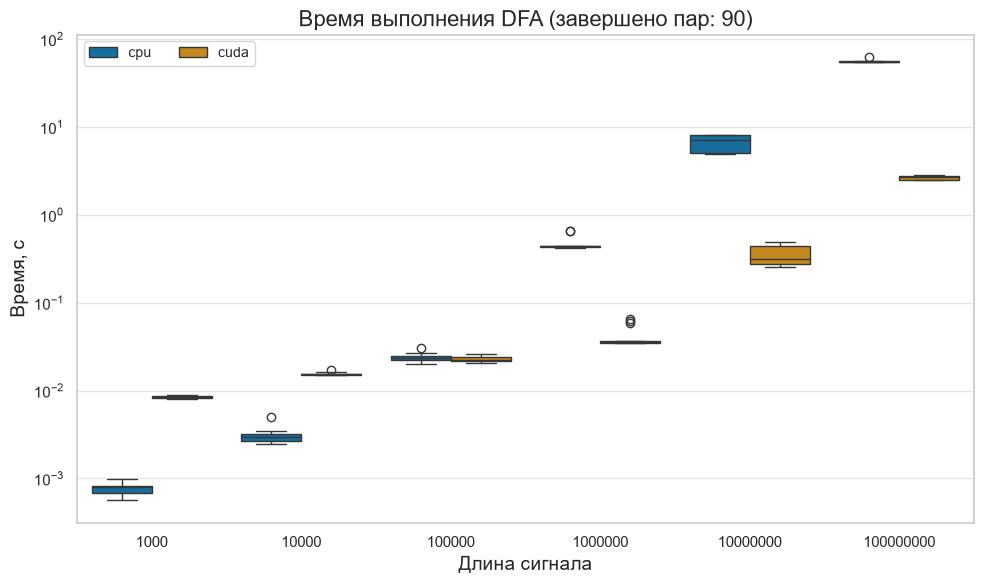

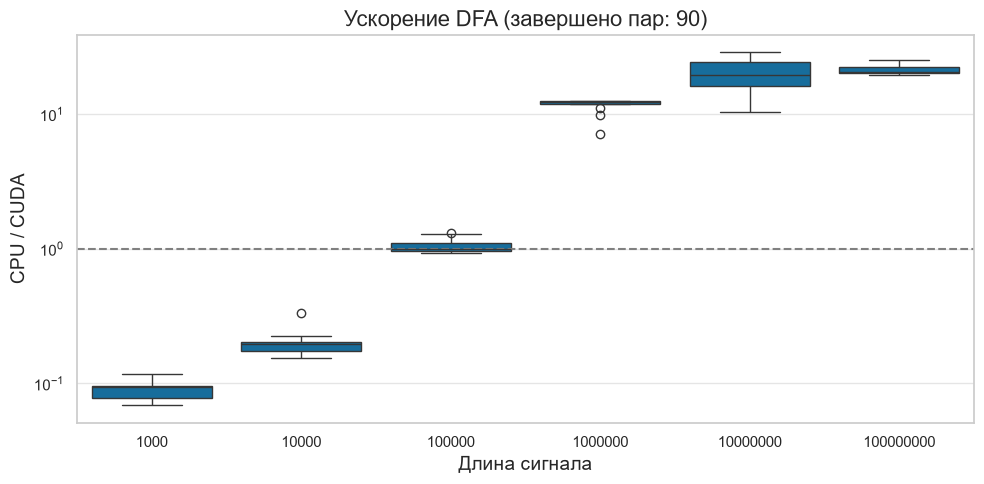

In [9]:
sns.set_theme(style="whitegrid", palette="colorblind")

label = f"завершено пар: {len(results)}"

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=times,
    x="size",
    y="seconds",
    hue="backend",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Длина сигнала", fontsize=14)
ax.set_ylabel("Время, с", fontsize=14)
ax.set_title(f"Время выполнения DFA ({label})", fontsize=16)
ax.legend(title=None, loc="upper left", ncol=2, fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=results,
    x="size",
    y="speedup",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Длина сигнала", fontsize=14)
ax.set_ylabel("CPU / CUDA", fontsize=14)
ax.set_title(f"Ускорение DFA ({label})", fontsize=16)
ax.axhline(1, color="gray", linestyle="--")
fig.tight_layout()
plt.show()
plt.close(fig)
